In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
df = pd.read_csv("noisy_curvefit_data.csv")

In [4]:
print(df.shape)
print(df.head())
print(df.tail())
df.describe()

(100, 6)
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2.500000,1.912465,2.060921,2.211000,2.443672,1.736289
std,2.051318,2.942506,3.270525,4.584177,4.585854,5.982601
min,-1.000000,-2.450502,-2.957248,-9.390142,-8.387941,-11.309062
25%,0.750000,0.148116,-0.222821,-0.974808,-1.034622,-3.151506
50%,2.500000,1.056779,1.330584,1.878554,2.002075,1.069983
75%,4.250000,2.534465,4.038781,4.335927,5.540654,6.720960
max,6.000000,11.624419,11.697543,18.246409,13.035831,15.529377


In [5]:
#100 rows, 6 columns
# Column names: x, y_noise_1, y_noise_2, y_noise_3, y_noise_4, y_noise_5

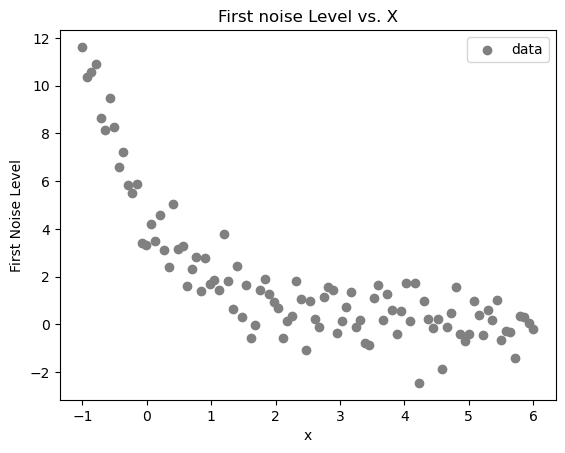

In [6]:
plt.scatter(df['x'], df['y_noise_1'], label = 'data', color = 'Grey')
plt.legend()
plt.title("First noise Level vs. X")
plt.xlabel("x")
plt.ylabel("First Noise Level")
plt.show()

In [7]:
def model(x, A, k):
    return A * np.exp(-k * x)
p0 = [1, 1]

popt, pcov = curve_fit(model, df['x'], df['y_noise_1'], p0=p0)
A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


0.79


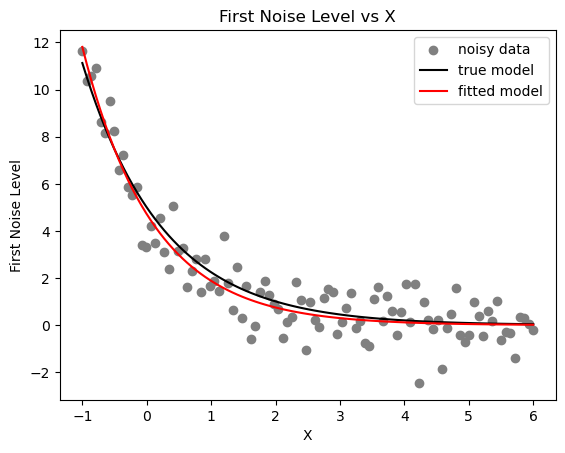

In [8]:
y_noise_1 = df['y_noise_1']
x = df['x']

residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
print(round(chi2_reduced, 2))

plt.scatter(x, y_noise_1, label = 'noisy data', color = 'Grey')
plt.plot(x, model(x, 5, 0.8), label = 'true model', color = 'black')
plt.plot(x, model(x, A_fit, k_fit), label = 'fitted model', color='red')
plt.xlabel('X')
plt.ylabel('First Noise Level')
plt.title('First Noise Level vs X')

plt.legend()

In [9]:
#2.3 comparing different noise levels

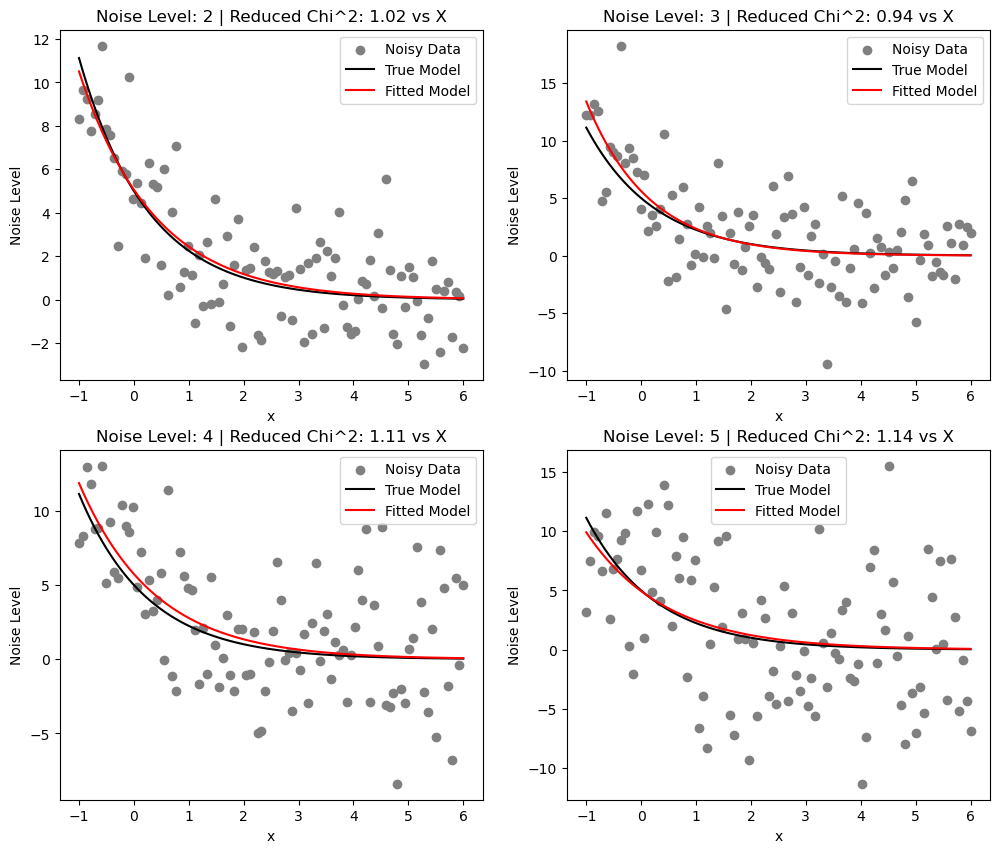

In [32]:
def fit_model(x, y):
    popt, pcov = curve_fit(model, x, y, p0)
    residuals = y_noise_1 - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return popt, chi2_reduced 

noise_levels = [2, 3, 4, 5]
columns = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']

plt.figure(figsize=(12, 10))

for i, col in enumerate(columns):
    plt.subplot(2, 2, i + 1)
    
    y_data = df[col]
    noise_val = noise_levels[i]
    
    popt, red_chi2 = fit_model(x, y_data)
    A_fit, k_fit = popt

    #remember to add chi reduced in title! will figure this out later
    plt.scatter(x, y_data, color='grey', label='Noisy Data')
    plt.plot(x, model(x, 5, 0.8), color = 'black', label='True Model') # Black line
    plt.plot(x, model(x, A_fit, k_fit), color = 'red', label='Fitted Model') # Red line
    plt.title(f"Noise Level: {noise_val} | Reduced Chi^2: {red_chi2:.2f} vs X")
    plt.xlabel("x")
    plt.ylabel("Noise Level")
    plt.legend()

In [ ]:
# The black dotted line stays the same, but the red line begins to deviate 
# further from the black line as the noise increases.

In [ ]:
#the reduced chi-squared value increases as the noise level increases.

In [33]:
results_list = []

noise_scenarios = [
    (1, 'y_noise_1'),
    (2, 'y_noise_2'),
    (3, 'y_noise_3'),
    (4, 'y_noise_4'),
    (5, 'y_noise_5')
]

for level, col in noise_scenarios:
    popt, red_chi2 = fit_model(df['x'], df[col])
    results_list.append({
        "Noise level": level,
        "A fit": popt[0],
        "k fit": popt[1],
        "Reduced chi-squared": red_chi2
    })

results_df = pd.DataFrame(results_list)
results_df.to_csv("noisy_parameters.csv", index=False)
print(results_df)

   Noise level     A fit     k fit  Reduced chi-squared
0            1  4.714814  0.918308             1.017713
1            2  5.063889  0.730396             1.017713
2            3  5.609396  0.870372             1.017713
3            4  5.738727  0.725965             1.017713
4            5  4.943458  0.695012             1.017713
